In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsbombpy import sb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.spatial import ConvexHull
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')
plt.rcdefaults() 


# --- STEP 1: SPATIAL COMPUTATION (CONVEX HULL) ---
def calculate_defensive_hull(event_frame):
    """Calculates the area (compactness) of the defending team's unit using Convex Hull."""
    opponents = event_frame[event_frame.teammate == False].copy()
    points = np.array(opponents['location'].tolist())
    
    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            return hull.area 
        except:
            return 0.0
    return 0.0

def extract_features(row, frames):
    """Extracts tactical features, integrating 360-degree spatial context."""
    event_frame = frames[frames.id == row.id]
    if event_frame.empty: return None
    
    passer_loc = np.array([row.x, row.y])
    opponents = event_frame[event_frame.teammate == False]
    
    # Tactical metric: Defensive Hull Area (Compactness)
    defensive_area = calculate_defensive_hull(event_frame)
    
    # Immediate Pressure: Distance to nearest defender
    if not opponents.empty:
        distances = opponents['location'].apply(lambda loc: np.linalg.norm(passer_loc - np.array(loc)))
        min_dist = distances.min()
    else:
        min_dist = 120 # Default max yardage
        
    return [
        len(opponents), 
        defensive_area, 
        min_dist, 
        row.pass_length, 
        row.pass_angle, 
        np.linalg.norm(passer_loc - np.array([120, 40])) # Dist to Goal Center
    ]


In [2]:
# --- STEP 2: DATA ACQUISITION & PROCESSING ---
matches = sb.matches(competition_id=43, season_id=106)
match_ids = matches.match_id.tolist()[:] # ALL MATCHES

X_list, y_list = [], []
print(f"🚀 Processing {len(match_ids)} World Cup Matches...")

for m_id in match_ids:
    events = sb.events(match_id=m_id)
    frames = sb.frames(match_id=m_id)
    
    # Clean locations
    mask = events.location.notnull()
    events[['x', 'y']] = pd.DataFrame(events.loc[mask, 'location'].tolist(), index=events[mask].index)
    
    passes = events[events.type == 'Pass'].copy()
    for _, row in passes.iterrows():
        feat = extract_features(row, frames)
        if feat:
            X_list.append(feat)
            y_list.append(1 if pd.isna(row.pass_outcome) else 0)


🚀 Processing 64 World Cup Matches...


In [3]:
# --- STEP 3: MODEL TRAINING ---
cols = ['num_opps', 'defensive_area', 'min_dist_opp', 'length', 'angle', 'dist_to_goal']
X = pd.DataFrame(X_list, columns=cols)
X_train, X_test, y_train, y_test = train_test_split(X, y_list, test_size=0.2, random_state=42)

print("\n🤖 Training XGBoost Tactical Model...")
model = XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



🤖 Training XGBoost Tactical Model...


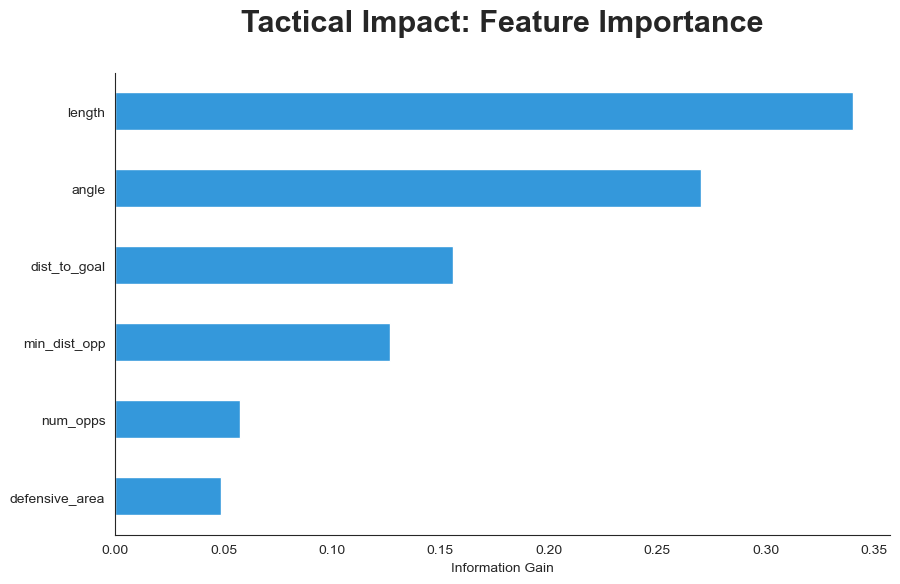

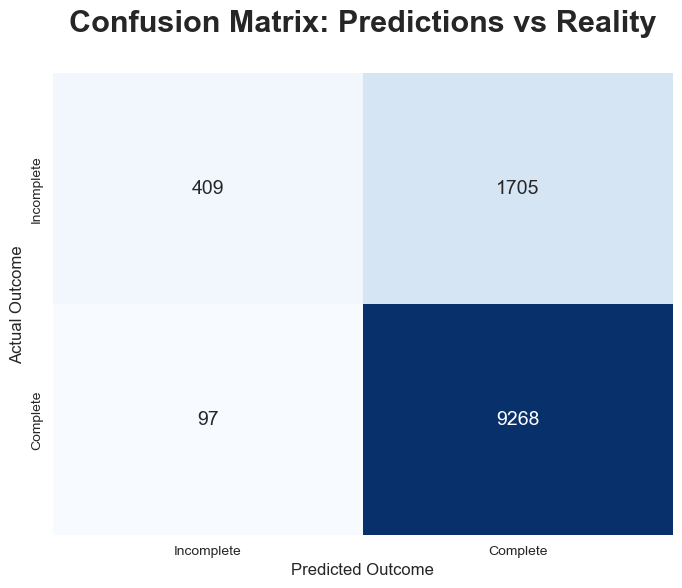

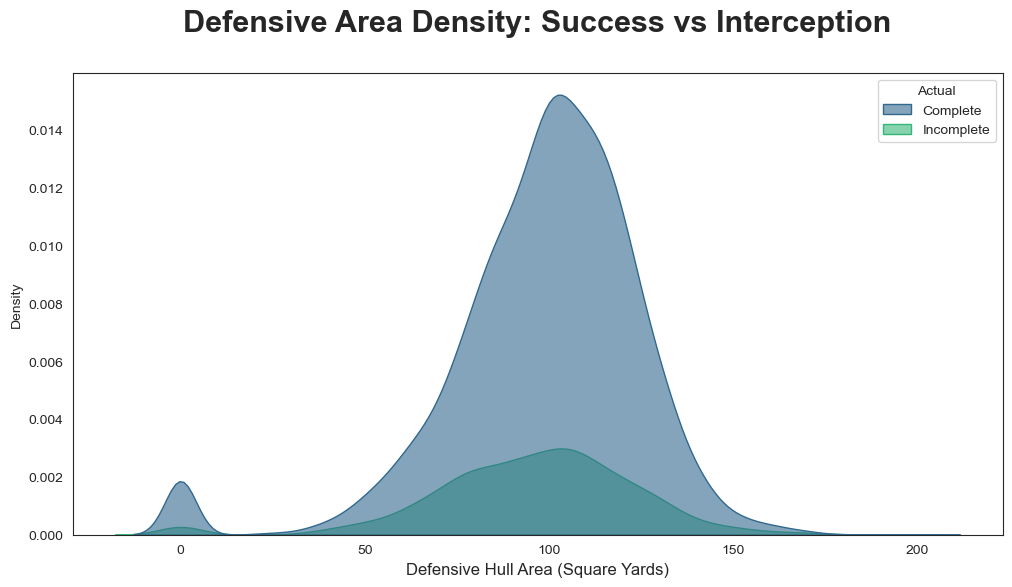

In [4]:
# --- STEP 4: INDIVIDUAL VISUALS ---
sns.set_style("white")
labels = ['Incomplete', 'Complete']
TITLE_CFG = {'fontsize': 22, 'fontweight': 'bold'}

# 1. Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=cols).sort_values()
importances.plot(kind='barh', color='#3498db')
plt.title("Tactical Impact: Feature Importance", fontdict=TITLE_CFG, pad=30)
plt.xlabel("Information Gain")
sns.despine()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
plt.title("Confusion Matrix: Predictions vs Reality", fontdict=TITLE_CFG, pad=30)
plt.xlabel("Predicted Outcome", fontsize=12)
plt.ylabel("Actual Outcome", fontsize=12)
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Defensive Density Plot
plt.figure(figsize=(12, 6))
temp_df = X_test.copy()
temp_df['Actual'] = pd.Series(y_test).map({0: 'Incomplete', 1: 'Complete'}).values
sns.kdeplot(data=temp_df, x='defensive_area', hue='Actual', fill=True, palette='viridis', alpha=0.6)
plt.title("Defensive Area Density: Success vs Interception", fontdict=TITLE_CFG, pad=30)
plt.xlabel("Defensive Hull Area (Square Yards)", fontsize=12)
plt.savefig("defensive_density.png", dpi=300, bbox_inches='tight')
plt.show()

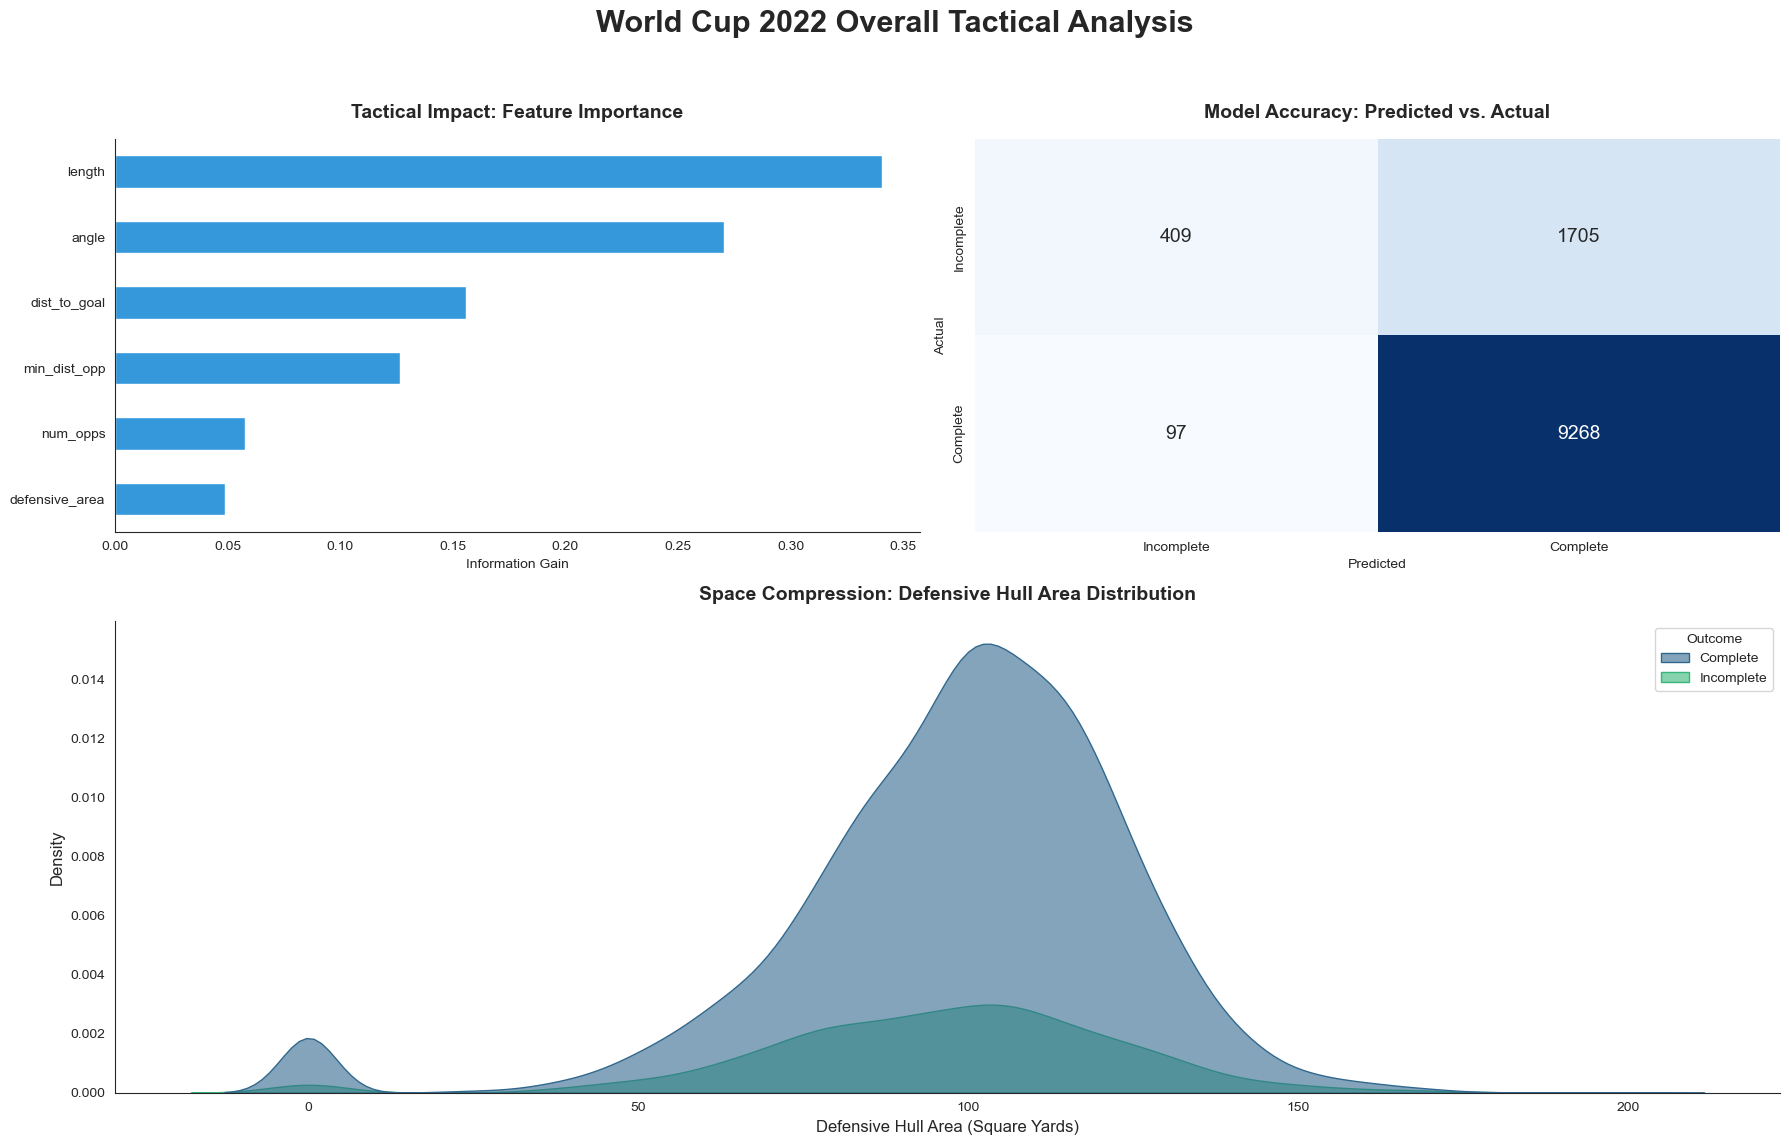

In [5]:
# --- STEP 5: INTEGRATED TACTICAL DASHBOARD ---
def generate_tactical_dashboard(model, X_test, y_test, y_pred, cols):
    sns.set_style("white")
    labels = ['Incomplete', 'Complete']
    
    # Style definitions - centralized to avoid alias errors
    TITLE_STYLE = {'fontsize': 22, 'fontweight': 'bold'} 
    SUB_STYLE = {'fontsize': 14, 'fontweight': 'bold'}

    fig = plt.figure(figsize=(18, 12), facecolor='white')
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

    # 1. Feature Importance
    ax1 = fig.add_subplot(gs[0, 0])
    importances = pd.Series(model.feature_importances_, index=cols).sort_values()
    importances.plot(kind='barh', color='#3498db', ax=ax1)
    ax1.set_title("Tactical Impact: Feature Importance", fontdict=SUB_STYLE, pad=15)
    ax1.set_xlabel("Information Gain")
    sns.despine(ax=ax1)

    # 2. Confusion Matrix
    ax2 = fig.add_subplot(gs[0, 1])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 14}, ax=ax2)
    ax2.set_title("Model Accuracy: Predicted vs. Actual", fontdict=SUB_STYLE, pad=15)
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("Actual")

    # 3. Defensive Density Plot
    ax3 = fig.add_subplot(gs[1, :])
    temp_df = X_test.copy()
    temp_df['Outcome'] = pd.Series(y_test).map({0: 'Incomplete', 1: 'Complete'}).values
    sns.kdeplot(data=temp_df, x='defensive_area', hue='Outcome', fill=True, 
                palette='viridis', alpha=0.6, ax=ax3)
    ax3.set_title("Space Compression: Defensive Hull Area Distribution", fontdict=SUB_STYLE, pad=15)
    ax3.set_xlabel("Defensive Hull Area (Square Yards)", fontsize=12)
    ax3.set_ylabel("Density", fontsize=12)
    sns.despine(ax=ax3)

    plt.suptitle("World Cup 2022 Overall Tactical Analysis", fontdict=TITLE_STYLE, y=0.98, fontsize = 22, weight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("world_cup_tactical_dashboard.png", dpi=300, bbox_inches='tight')
    plt.show()

# Generate the dashboard
generate_tactical_dashboard(model, X_test, y_test, y_pred, cols)


In [6]:
# --- STEP 6: PERFORMANCE REPORT ---
report = classification_report(y_test, y_pred, target_names=labels, output_dict=True)
table_data = [
    ["Incomplete Pass", report['Incomplete']['precision'], report['Incomplete']['recall'], report['Incomplete']['f1-score']],
    ["Complete Pass", report['Complete']['precision'], report['Complete']['recall'], report['Complete']['f1-score']],
    ["OVERALL ACCURACY", "", "", report['accuracy']]
]

print("\n" + "="*65)
print("      🛡️ WORLD CUP 2022: DEFENSIVE COMPACTNESS ANALYTICS 🛡️")
print("="*65)
print(tabulate(table_data, headers=["Category", "Precision", "Recall", "F1-Score"], tablefmt="fancy_grid", floatfmt=".4f"))


      🛡️ WORLD CUP 2022: DEFENSIVE COMPACTNESS ANALYTICS 🛡️
╒══════════════════╤════════════════════╤════════════════════╤════════════╕
│ Category         │ Precision          │ Recall             │   F1-Score │
╞══════════════════╪════════════════════╪════════════════════╪════════════╡
│ Incomplete Pass  │ 0.808300395256917  │ 0.1934720908230842 │     0.3122 │
├──────────────────┼────────────────────┼────────────────────┼────────────┤
│ Complete Pass    │ 0.8446186093137702 │ 0.989642285104111  │     0.9114 │
├──────────────────┼────────────────────┼────────────────────┼────────────┤
│ OVERALL ACCURACY │                    │                    │     0.8430 │
╘══════════════════╧════════════════════╧════════════════════╧════════════╛
